In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [96]:
def update_q(q, omega, ds, kappa):
    p1 = np.fft.fft(np.exp(-N * ds * omega / 2) * q)
    p2 = np.fft.ifft(np.exp(-(Re * kappa) ** 2 * ds / 6) * p1).real
    q_new = np.exp(-N * omega * ds / 2) * p2
    return q_new

def SCFT_solver(delta, x_mesh, ss, ds, max_iters, tol, large_number):
    omega = np.zeros(len(x_mesh))
    omega[0] = large_number
    omega[1] = large_number
    omega_store = [omega.copy()]
    
    for iter_ in range(max_iters):
        omega_old = omega.copy()
    
        q = np.ones(len(x_mesh))
        q[:2] = 0  # BC @ x < grafting point
    
        q_dagger = np.zeros(len(x_mesh))
        q_dagger[:2] = 0
        q_dagger[3] = 1 / dx  # Grafting Point @ x = 0
    
        q_store = [q.copy()]
        q_dagger_store = [q_dagger.copy()]
    
        for s in ss:
            q = update_q(q, omega, ds, kappa)
            q[:2] = 0 # BC @ x < grafting point
            q_store.append(q.copy())
            
            q_dagger = update_q(q_dagger, omega, ds, kappa)
            q_dagger[:2] = 0 # BC @ x < grafting point
            q_dagger_store.append(q_dagger.copy())
            
        q_dagger_store = q_dagger_store[::-1] 
    
        rho_tilde = np.zeros(len(x_mesh))
        for idx in range(len(ss) + 1):
            rho_tilde += q_store[idx] * q_dagger_store[idx] * ds
    
        norm = np.sum(q_store[0] * q_dagger_store[-1]) / Re
        rho_tilde /= norm
    
        omega = delta / N * rho_tilde
        omega[0] = large_number
        omega[1] = large_number
        omega_store.append(omega.copy())
    
        if np.linalg.norm(omega - omega_old) < tol:
            print(f"Converged at iteration {iter_} for delta = {delta}")
            return [q_store, q_dagger_store], omega, rho_tilde
            
def rho_tilde_analytical_expr(x, delta, Re):
    h = Re*((4*delta)/np.pi**2)**(1/3)
    rho_tilde = (3*Re)/(2*h)*(1-(x/h)**2)
    rho_tilde[x > h] = 0  # Zero out values where x > h

    return rho_tilde

def chain_end_analytical_expr(x, delta, Re):
    h = Re * ((4*delta)/np.pi**2)**(1/3)
    end_dist = np.zeros_like(x)
    end_dist[x <= h] = x[x <= h] * np.sqrt(h**2 - x[x <= h]**2)
    return end_dist

def F_analytical(delta):
    return (3/5)*((27/32)*np.pi**2)**(1/3)*delta**(2/3)

In [20]:
# Parameters
Re = 1 # End-to-end distance
N = 25
# v = 0.35 # virial
v = np.linspace(0.001, 0.35, 10)
sigma = 0.1 # Grafting density
delta = N**2 * v * sigma / Re
print(delta)

# Mesh
L = 5
x_gridPoints = 30 # +2 from infinite potentials below the grafting point (@ x = 0)
x_mesh = np.linspace(0, L, x_gridPoints)
dx = x_mesh[1] - x_mesh[0]
x_mesh = np.insert(x_mesh, 0, -dx)      # Extra point for left boundary
x_mesh = np.insert(x_mesh, 0, -2 * dx)  # Extra point for left boundary

# Reciprocal mesh
kappa = 2 * np.pi * np.fft.fftfreq(len(x_mesh), d=dx)

# Solver
ds = 0.001
ss = np.arange(0, 1 + ds, ds)
max_iters = 1000
tol = 1e-6
large_number = 1e6

[ 0.0625      2.48611111  4.90972222  7.33333333  9.75694444 12.18055556
 14.60416667 17.02777778 19.45138889 21.875     ]


In [82]:
rho_tildes = []
omegas = []
q_stores = []
q_dagger_stores = []

for d in delta:
    [q_store, q_dagger_store], omega, rho_tilde = SCFT_solver(d, x_mesh, ss, ds, max_iters, tol, large_number)
    rho_tildes.append(rho_tilde)
    omegas.append(omega)
    q_stores.append(q_store)
    q_dagger_stores.append(q_dagger_store)

Converged at iteration 2 for delta = 0.0625
Converged at iteration 6 for delta = 2.4861111111111107
Converged at iteration 9 for delta = 4.909722222222221
Converged at iteration 12 for delta = 7.333333333333333
Converged at iteration 16 for delta = 9.756944444444443
Converged at iteration 20 for delta = 12.180555555555555
Converged at iteration 24 for delta = 14.604166666666666
Converged at iteration 30 for delta = 17.027777777777775
Converged at iteration 37 for delta = 19.451388888888886
Converged at iteration 47 for delta = 21.875


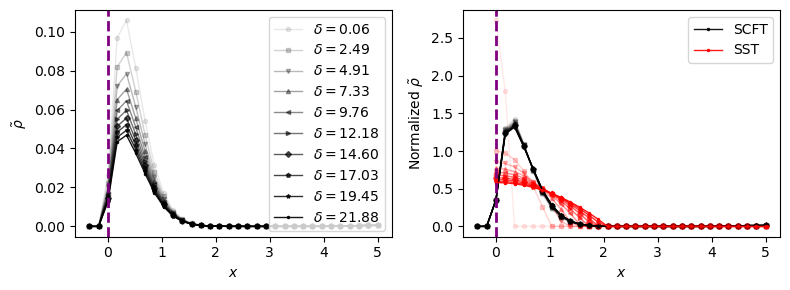

In [83]:
fig, ax = plt.subplots(1, 2, figsize = (8, 3))

marker_list = ["o", "s", "v", "^", "<", ">", "D", "p", "*", "."]
for idx, rho_tilde in enumerate(rho_tildes[::]):
    label = r"$\delta=$" + f"{delta[idx]:.2f}"
    ax[0].plot(x_mesh, rho_tilde, marker = marker_list[idx], color = "k", label = label, linewidth = 1, markersize = 3, alpha = (idx+1)/(len(rho_tildes)+1))
ax[0].axvline(0, linewidth = 2, color = "purple", linestyle = "--")
ax[0].legend(loc = "upper right")
ax[0].set_xlabel(r"$x$")
ax[0].set_ylabel(r"$\tilde{\rho}$")

for idx, rho_tilde in enumerate(rho_tildes[::]):
    label = r"$\delta=$" + f"{delta[idx]:.2f}"
    rho_tilde_normed = rho_tilde/np.trapz(rho_tilde, x=x_mesh)
    
    rho_tilde_analytical = rho_tilde_analytical_expr(x_mesh, delta[idx], Re)
    rho_tilde_analytical_normed = rho_tilde_analytical_expr(x_mesh, delta[idx], Re)/np.trapz(rho_tilde_analytical, x=x_mesh)

    if idx == len(rho_tildes[::])-1:
        ax[1].plot(x_mesh, rho_tilde_normed, marker=marker_list[idx], color="k", label="SCFT", linewidth=1, markersize=3, alpha=(idx+1)/(len(rho_tildes)+1))
        ax[1].plot(x_mesh[2:], rho_tilde_analytical_normed[2:], marker=marker_list[idx], color="r", label="SST", linewidth=1, markersize=3, alpha=(idx+1)/(len(rho_tildes)+1))
    else:
        ax[1].plot(x_mesh, rho_tilde_normed, marker=marker_list[idx], color="k", linewidth=1, markersize=3, alpha=(idx+1)/(len(rho_tildes)+1))
        ax[1].plot(x_mesh[2:], rho_tilde_analytical_normed[2:], marker=marker_list[idx], color="r", linewidth=1, markersize=3, alpha=(idx+1)/(len(rho_tildes)+1))

ax[1].legend(loc = "upper right")
ax[1].set_xlabel(r"$x$")
ax[1].set_ylabel(r"Normalized $\tilde{\rho}$")
ax[1].axvline(0, linewidth = 2, color = "purple", linestyle = "--")

fig.tight_layout()

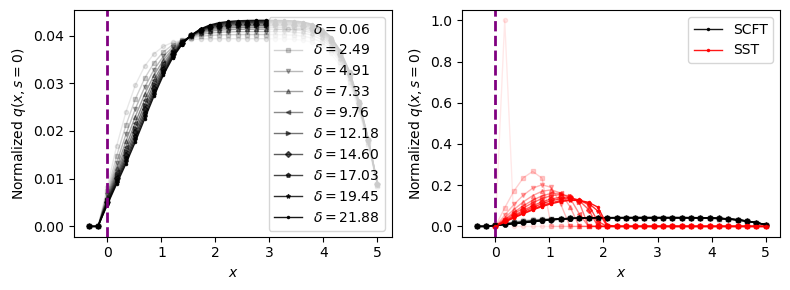

In [99]:
fig, ax = plt.subplots(1, 2, figsize = (8, 3))
for idx, rho_tilde in enumerate(rho_tildes[::]):
    label = r"$\delta=$" + f"{delta[idx]:.2f}"
    ax[0].plot(x_mesh, q_stores[idx][-1]/np.sum(q_stores[idx][-1]), marker = marker_list[idx], color = "k", label = label, linewidth = 1, markersize = 3, alpha = (idx+1)/(len(rho_tildes)+1))

ax[0].axvline(0, linewidth = 2, color = "purple", linestyle = "--")
ax[0].legend(loc = "upper right")
ax[0].set_xlabel(r"$x$")
ax[0].set_ylabel(r"Normalized $q(x, s=0)$");

for idx, rho_tilde in enumerate(rho_tildes[:]):
    label = r"$\delta=$" + f"{delta[idx]:.2f}"
    end_dist_analytical = chain_end_analytical_expr(x_mesh[2:], delta[idx], Re)
    end_dist_analytical_normed = end_dist_analytical/np.sum(end_dist_analytical)

    if idx == len(rho_tildes[::])-1:
        ax[1].plot(x_mesh, q_stores[idx][-1]/np.sum(q_stores[idx][-1]), marker=marker_list[idx], color="k", label="SCFT", linewidth=1, markersize=3, alpha=(idx+1)/(len(rho_tildes)+1))
        ax[1].plot(x_mesh[2:], end_dist_analytical_normed, marker=marker_list[idx], color="r", label="SST", linewidth=1, markersize=3, alpha=(idx+1)/(len(rho_tildes)+1))
    else:
        ax[1].plot(x_mesh, q_stores[idx][-1]/np.sum(q_stores[idx][-1]), marker=marker_list[idx], color="k", linewidth=1, markersize=3, alpha=(idx+1)/(len(rho_tildes)+1))
        ax[1].plot(x_mesh[2:], end_dist_analytical_normed, marker=marker_list[idx], color="r", linewidth=1, markersize=3, alpha=(idx+1)/(len(rho_tildes)+1))


ax[1].legend(loc = "upper right")
ax[1].set_xlabel(r"$x$")
ax[1].set_ylabel(r"Normalized $q(x, s = 0)$")
ax[1].axvline(0, linewidth = 2, color = "purple", linestyle = "--")

fig.tight_layout()

Text(0, 0.5, 'F')

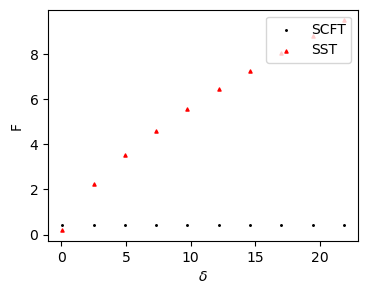

In [147]:
fig, ax = plt.subplots(figsize = (4, 3))

for idx, rho_tilde in enumerate(rho_tildes[:]):
    label = r"$\delta=$" + f"{delta[idx]:.2f}"
    F = 0
    F += np.trapz(q_stores[0][-1]*q_dagger_stores[0][-1], x_mesh)/Re
    F -= 0.5*np.trapz(delta[idx]*rho_tilde**2, x_mesh)/Re
    # print(F, F_analytical(delta[idx]))

    if idx == len(rho_tildes[::])-1:
        ax.scatter(delta[idx], F, color="k", s=5, marker=".", label="SCFT")
        ax.scatter(delta[idx], F_analytical(delta[idx]), color="r", s=5, marker="^", label="SST")
        
    else:
        ax.scatter(delta[idx], F, color="k", s=5, marker=".")
        ax.scatter(delta[idx], F_analytical(delta[idx]), color="r", s=5, marker="^")
ax.legend(loc = "upper right")
ax.set_xlabel(r"$\delta$")
ax.set_ylabel(r"F")

In [74]:
# omega = np.zeros(len(x_mesh))
# omega[0] = large_number
# omega[1] = large_number
# omega_store = [omega.copy()]

# for iter_ in tqdm(range(max_iters)):
#     omega_old = omega.copy()

#     # Initialize forward propagator q(x, 0)
#     q = np.ones(len(x_mesh))
#     q[:2] = 0  # Boundary condition at grafting point

#     # Initialize backward propagator q†(x, 1)
#     q_dagger = np.zeros(len(x_mesh))
#     q_dagger[:2] = 0
#     q_dagger[3] = 1 / dx  # Delta function normalized at grafting point

#     q_store = [q.copy()]
#     q_dagger_store = [q_dagger.copy()]

#     # Forward propagate q
#     for s in ss:
#         q = update_q(q, omega, ds, kappa)
#         q[:2] = 0  # Enforce boundary condition
#         q_store.append(q.copy())
        
#         q_dagger = update_q(q_dagger, omega, ds, kappa)
#         q_dagger[:2] = 0
#         q_dagger_store.append(q_dagger.copy())
#     q_dagger_store = q_dagger_store[::-1]  # Reverse to match q

#     # Compute monomer density ρ̃(x)
#     rho_tilde = np.zeros(len(x_mesh))
#     for idx in range(len(ss) + 1):
#         rho_tilde += q_store[idx] * q_dagger_store[idx] * ds

#     # Normalize ρ̃(x)
#     norm = np.sum(q_store[0] * q_dagger_store[-1]) / Re
#     rho_tilde /= norm

#     # Update ω(x)
#     omega = delta / N * rho_tilde
#     omega[0] = large_number
#     omega[1] = large_number
#     omega_store.append(omega.copy())

#     # Convergence check
#     if np.linalg.norm(omega - omega_old) < tol:
#         print(f"Converged at iteration {iter_}")
#         break

In [75]:
# fig, ax = plt.subplots(figsize = (4, 3))

# ax.scatter(x_mesh[2:], omega[2:], label=r"$\omega$", color="red", marker = "^", s=10)
# ax.scatter(x_mesh[2:], rho_tilde[2:], label=r"$\tilde{\rho}$", color="black", marker="s", s=10)
# ax.legend()
# ax.set_xlabel(r"$x$")
# title = r"$(R_e, N, v, \sigma) = $(" + f"{Re}, {N}, {v}, {sigma})" + "\n" + r"$\delta = $" + f"{delta}"
# ax.set_title(title)


In [140]:
# fig, ax = plt.subplots(figsize = (4, 3))

# ax.scatter(x_mesh[2:], omega[2:], label=r"$\omega$", color="red", marker = "^", s=10)
# ax.scatter(x_mesh[2:], rho_tilde[2:], label=r"$\tilde{\rho}$", color="black", marker="s", s=10)
# ax.legend()
# ax.set_xlabel(r"$x$")
# title = r"$(R_e, N, v, \sigma) = $(" + f"{Re}, {N}, {v}, {sigma})" + "\n" + r"$\delta = $" + f"{delta}"
# ax.set_title(title)


In [76]:
# fig, ax = plt.subplots(1, 2, figsize = (8, 3))
# ax[0].scatter(x_mesh, q_store[0], color="black", marker = "^", s=1, label = r"$q(x, 0)$")
# ax[0].scatter(x_mesh, q_store[-1], color="red", marker="s", s=1, label = r"$q(x, 1)$")
# # ax[0].set_yscale("log")
# ax[0].legend()

# ax[1].scatter(x_mesh, q_dagger_store[-1], color="black", marker="s", s=1, label = r"$q^\dagger(x, 0)$")
# ax[1].scatter(x_mesh, q_dagger_store[0], color="red", marker = "^", s=1, label = r"$q^\dagger(x, 1)$")
# # ax[1].set_yscale("log")
# ax[1].legend();


